In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path
import btrack, numpy as np, pandas as pd
from btrack.constants import BayesianUpdates
from scipy.stats import zscore
from scipy.signal import savgol_filter

from scipy.stats import binned_statistic_2d
from scipy.signal import savgol_filter

import anndata as an
import scanpy as sc
from collections import Counter
from matplotlib.patches import Patch
import warnings

# tracking algs
import trackpy as tp

# Load in data

In [2]:
%%time
dpath = "/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/"
file_list = glob.glob(f"{dpath}*_*_*.csv") # exclude the test image

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


df = pd.concat(df_list)
print(f"{df.shape=}")

df['cell_id'] = df['basename'] + "_label" + df['label'].astype(str)

# shift stage 2 times to follow after stage 1
max_time_stage1 = df.loc[df["stage"] == 1, "time"].max()
df["time_shifted"] = df["time"] + (
    (df["stage"] == 2) * (max_time_stage1 + 1)
)

df.head()

	02_siPRRX1_B3_props df.shape=(188240, 49)
	01_mmMYOD1_D4_props df.shape=(35964, 49)
	01_control_D2_props df.shape=(31271, 49)
	01_hybrid_C3_props df.shape=(49123, 49)
	01_mmMYOD1_D3_props df.shape=(33663, 49)
	02_hybrid_C6_props df.shape=(123894, 49)
	02_hybrid_C4_props df.shape=(145648, 49)
	01_hybrid_C4_props df.shape=(64240, 49)
	02_mmMYOD1_D4_props df.shape=(72217, 49)
	02_siPRRX1_B4_props df.shape=(198826, 49)
	02_hybrid_C3_props df.shape=(133759, 49)
	01_hybrid_C6_props df.shape=(57297, 49)
	01_control_C2_props df.shape=(39967, 49)
	02_mmMYOD1_D3_props df.shape=(68484, 49)
	01_siPRRX1_B4_props df.shape=(80394, 49)
	02_control_C2_props df.shape=(94187, 49)
	01_siPRRX1_B3_props df.shape=(70595, 49)
	01_control_B2_props df.shape=(40213, 49)
	02_control_D2_props df.shape=(65965, 49)
	02_control_B2_props df.shape=(91039, 49)
df.shape=(1684986, 49)
CPU times: user 11 s, sys: 1.43 s, total: 12.5 s
Wall time: 14.1 s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,29.239852,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,11.038021,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,16.582590,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,135.223725,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,30.855447,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67


In [3]:
## Subset for only 2 wells for testing

wells = [
    '01_control_B2_props',
    '02_control_B2_props',
]

df = df[df['basename'].isin(wells)].copy()
print(df.shape)
df.head()

(131252, 51)


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,134.0,872,2594,889,2607,221.0,880.320896,2600.761194,0.855268,...,10.420536,0,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label1,0
1,2,149.0,592,647,610,658,198.0,600.476510,652.328859,0.849325,...,13.639911,0,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label2,0
2,3,164.0,492,1118,505,1134,208.0,497.817073,1125.475610,0.677989,...,32.055477,0,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label3,0
3,4,118.0,1331,2746,1344,2759,169.0,1336.661017,2751.932203,0.798253,...,24.254465,0,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label4,0
4,5,131.0,129,2808,146,2819,187.0,137.137405,2812.687023,0.879899,...,16.122084,0,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label5,0


# Visualize reporters

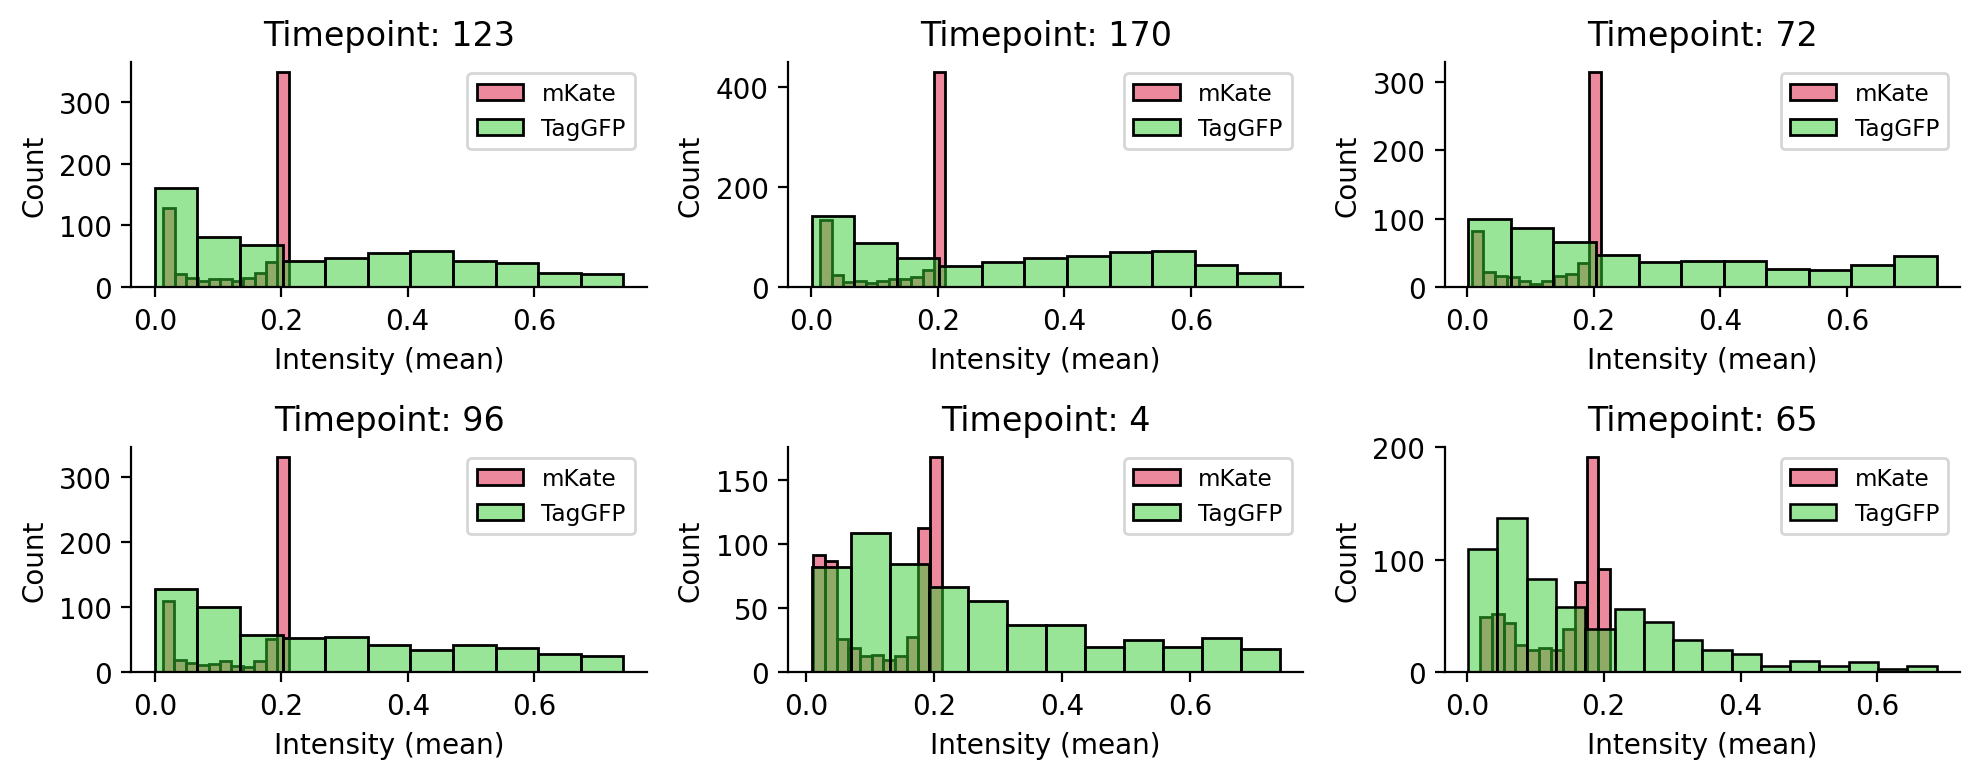

In [4]:
# pick 6 random time points
timepoints = np.random.choice(df["time_shifted"].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=200)

for ax, time in zip(axes.flatten(), timepoints):
    subset = df[df['time_shifted'] == time]

    sns.histplot(
        data=subset,
        x='mKate_mean',
        color='crimson',
        alpha=0.5,
        label='mKate',
        ax=ax
    )

    sns.histplot(
        data=subset,
        x='TaGFP_mean',
        color='limegreen',
        alpha=0.5,
        label='TagGFP',
        ax=ax
    )

    ax.set_title(f"Timepoint: {time}")
    ax.set_xlabel("Intensity (mean)")
    ax.set_ylabel("Count")
    ax.legend(fontsize='small')

sns.despine()
plt.tight_layout()
plt.show()

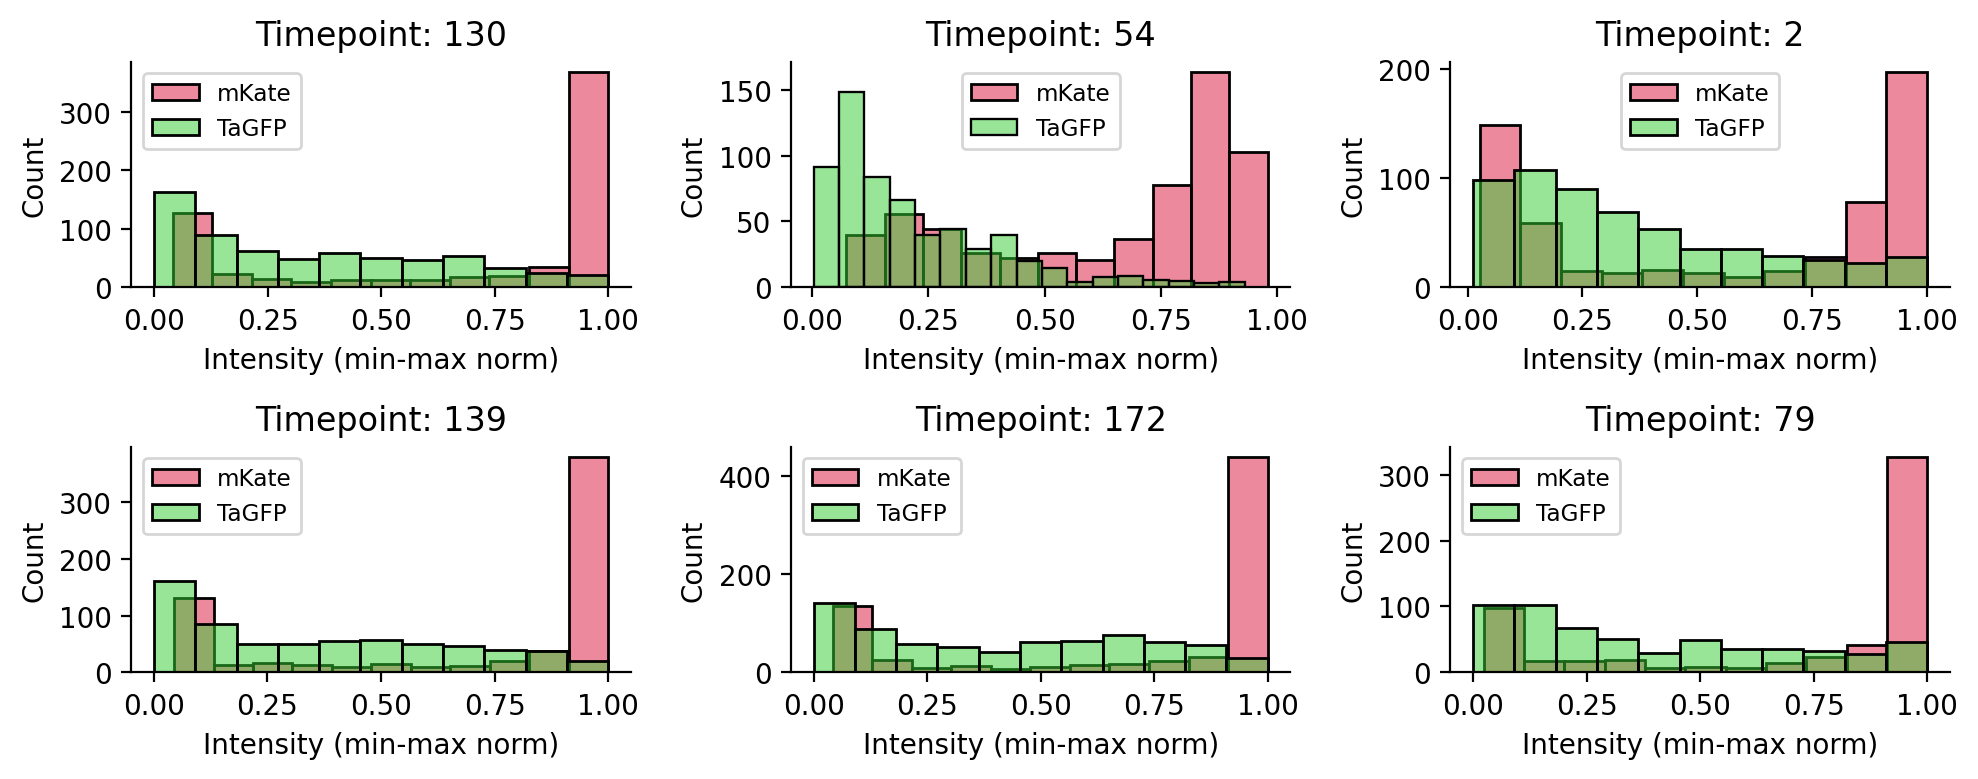

In [5]:
# Simple normalization (min-max)
df['TaGFP_norm'] = (df['TaGFP_mean'] - df['TaGFP_mean'].min()) / (df['TaGFP_mean'].max() - df['TaGFP_mean'].min())
df['mKate_norm'] = (df['mKate_mean'] - df['mKate_mean'].min()) / (df['mKate_mean'].max() - df['mKate_mean'].min())

# pick 6 random time points
timepoints = np.random.choice(df["time_shifted"].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=200)
# fig, axes = plt.subplots(3, 2, figsize=(7, 6), dpi=200)

for ax, time in zip(axes.flatten(), timepoints):
    subset = df[df['time_shifted'] == time]

    sns.histplot(
        data=subset,
        x='mKate_norm',
        color='crimson',
        alpha=0.5,
        label='mKate',
        ax=ax
    )

    sns.histplot(
        data=subset,
        x='TaGFP_norm',
        color='limegreen',
        alpha=0.5,
        label='TaGFP',
        ax=ax
    )

    ax.set_title(f"Timepoint: {time}")
    ax.set_xlabel("Intensity (min-max norm)")
    ax.set_ylabel("Count")
    ax.legend(fontsize='small')

sns.despine()
plt.tight_layout()
plt.show()

# Track cells

In [6]:
%%time
### --- Tracking by stage ---
# Rename columns for trackpy
pdf = df.rename(columns={
    "time": "frame",
    "centroid_x_px": "x",
    "centroid_y_px": "y"
}).copy()

# Store all per-(cond,scene,stage) tracking results in a list
all_track_dfs = []

for (cond, scene, stage), g in pdf.groupby(["condition", "scene", "stage"]):
    print(f"Tracking: {(cond, scene, stage)}")
    g_sorted = g.sort_values("frame")
    
    # Run tracking
    linked = tp.link_df(
        g_sorted,
        search_range=55,        # adjust as needed
        memory=5,
        adaptive_stop=True
    )
    
    # Add context columns
    linked["condition"] = cond
    linked["scene"] = scene
    linked["stage"] = stage
    
    # Optionally filter out short tracks (e.g., less than 50 frames)
    linked = tp.filter_stubs(linked, threshold=10)
    
    print(f"\tlinked.shape: {linked.shape}")
    
    all_track_dfs.append(linked)

# Combine all per-stage results
all_traj = pd.concat(all_track_dfs, ignore_index=True)
print(f"All tracked data shape: {all_traj.shape}")

Frame 136: 799 trajectories present.
	linked.shape: (89059, 54)
All tracked data shape: (128049, 54)
CPU times: user 3.82 s, sys: 264 ms, total: 4.09 s
Wall time: 5.28 s


In [7]:
all_traj['particle_id'] = all_traj['stage'].astype(str) + '_' + all_traj['condition'] + '_' + all_traj['scene'] + '_' + all_traj['particle'].astype(str)

columns_to_keep = [
    'condition', 'scene', 'stage', 'particle', 'particle_id', 'frame', 'time_shifted',
    'filled_area', 'Cy5_mean', 'TaGFP_mean', 'mKate_mean', 'x', 'y',
]

all_traj = all_traj[columns_to_keep]

all_traj.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647
1,control,B2,1,2,1_control_B2_2,0,0,107.0,0.094927,0.234181,0.180446,232.588785,2579.112150
2,control,B2,1,3,1_control_B2_3,0,0,118.0,0.037478,0.136275,0.193143,616.525424,551.245763
3,control,B2,1,4,1_control_B2_4,0,0,157.0,0.040521,0.247596,0.201448,1693.929936,2509.847134
4,control,B2,1,5,1_control_B2_5,0,0,86.0,0.107119,0.047916,0.010504,2243.581395,2229.174419


In [8]:
print(all_traj.shape)

(128049, 13)


In [9]:
all_traj[all_traj['stage'] == 2].head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y
38990,control,B2,2,0,2_control_B2_0,0,67,191.0,0.690293,0.282676,0.187734,1143.842932,81.130890
38991,control,B2,2,1,2_control_B2_1,0,67,188.0,0.713169,0.017426,0.107638,1184.478723,26.877660
38992,control,B2,2,2,2_control_B2_2,0,67,115.0,0.680620,0.544714,0.204041,231.800000,814.539130
38993,control,B2,2,3,2_control_B2_3,0,67,194.0,0.683551,0.358278,0.193757,552.757732,2177.768041
38994,control,B2,2,5,2_control_B2_5,0,67,194.0,0.671675,0.352159,0.187699,511.231959,1872.469072


# Filter trajectories

In [10]:
# calculate total trajectory length per cell
all_traj['path_length'] = all_traj.groupby('particle_id')['frame'].transform(lambda x: x.nunique())

all_traj.groupby('condition')['path_length'].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,128049.0,90.172067,39.487357,10.0,66.0,76.0,137.0,137.0


In [11]:
tdf = all_traj.copy()
print(f"N cells: {tdf['particle_id'].nunique()}")

min_path_length = 50

# remove short trajectories
tdf = tdf[tdf['path_length'] >= min_path_length]
print(f"N cells with at least 50 frames: {tdf['particle_id'].nunique()}\n")

# assess trajectory gaps
tdf = tdf.sort_values(['particle_id', 'frame'])

tdf['frame_diff'] = tdf.groupby('particle_id')['frame'].diff()

# Find gaps (diff > 1)
tdf['gap_length'] = tdf['frame_diff'] - 1
tdf['gap_length'] = tdf['gap_length'].where(tdf['gap_length'] > 0, 0)  # set negative/0 diffs to 0

gap_info = tdf.groupby('particle_id')['gap_length'].agg([
    ('has_gap', lambda x: x.gt(0).any()),
    ('max_gap_length', 'max')
]).reset_index()

# Merge flag and gap info back to the original dataframe
tdf = tdf.merge(gap_info, on='particle_id')
tdf = tdf.drop(columns=['frame_diff'])

print(f"{tdf.drop_duplicates('particle_id')['has_gap'].value_counts()}\n")

tdf.drop_duplicates('particle_id').groupby('condition')['max_gap_length'].describe()

N cells: 1965
N cells with at least 50 frames: 1212

has_gap
False    903
True     309
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,1212.0,0.693069,1.391796,0.0,0.0,0.0,1.0,5.0


In [13]:
print(tdf.shape)
tdf.head()

(108702, 17)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0


In [14]:
tdf['particle_id'].nunique()

1212

In [47]:
tmp = tdf[tdf['stage'] == 2].copy()

print(tmp.shape)
tmp.head()

(75569, 17)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length
33133,control,B2,2,1,2_control_B2_1,0,67,188.0,0.713169,0.017426,0.107638,1184.478723,26.877660,132,0.0,True,3.0
33134,control,B2,2,1,2_control_B2_1,1,68,185.0,0.696138,0.012529,0.092934,1183.362162,24.151351,132,0.0,True,3.0
33135,control,B2,2,1,2_control_B2_1,2,69,173.0,0.687088,0.011150,0.090683,1183.011561,22.531792,132,0.0,True,3.0
33136,control,B2,2,1,2_control_B2_1,3,70,161.0,0.657065,0.011619,0.091213,1182.236025,21.664596,132,0.0,True,3.0
33137,control,B2,2,1,2_control_B2_1,4,71,146.0,0.652929,0.014706,0.099172,1179.794521,25.054795,132,0.0,True,3.0


In [66]:
def clean_and_normalize_fucci(group):
    # If a track is too short, skip it
    if len(group) < 5:
        return group

    # 1. Kill single-frame spikes using a 3-frame rolling median
    # (center=True ensures no phase-shifting/lagging in time)
    red_clean = group['mKate_mean'].rolling(window=3, center=True, min_periods=1).median()
    green_clean = group['TaGFP_mean'].rolling(window=3, center=True, min_periods=1).median()
    
    # 2. Min-Max Normalize the cleaned tracks
    rk_min, rk_max = red_clean.min(), red_clean.max()
    gr_min, gr_max = green_clean.min(), green_clean.max()
    
    if (rk_max - rk_min) == 0 or (gr_max - gr_min) == 0:
        return group
        
    red_norm = (red_clean - rk_min) / (rk_max - rk_min)
    green_norm = (green_clean - gr_min) / (gr_max - gr_min)
    
    # 3. Gentle Savgol smooth to polish out camera hiss before arctan2
    group['mKate_processed'] = savgol_filter(red_norm, window_length=9, polyorder=2).clip(0, 1)
    group['TagGFP_processed'] = savgol_filter(green_norm, window_length=9, polyorder=2).clip(0, 1)
    
    # 4. Compute the final clean angle
    group['FUCCI_angle'] = np.arctan2(group['TagGFP_processed'], group['mKate_processed'])
    
    return group


tmp = tdf.copy()
print(tmp.shape)

processed_df = tmp.groupby('particle_id', observed=True).apply(clean_and_normalize_fucci).reset_index(drop=True)
print(processed_df.shape)
processed_df.head()

(108702, 17)
(108702, 20)


/tmp/ipykernel_1698142/216877174.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  processed_df = tmp.groupby('particle_id', observed=True).apply(clean_and_normalize_fucci).reset_index(drop=True)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length,mKate_processed,TagGFP_processed,FUCCI_angle
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0,0.966566,0.788415,0.684233
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0,0.902970,0.644137,0.619631
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0,0.849192,0.524392,0.553202
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0,0.805229,0.429181,0.489692
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0,0.771082,0.358504,0.435205


In [74]:
tmp = tdf.copy()
print(tmp.shape)


# ==========================================
# STEP 1: CALCULATE GLOBAL BOUNDS
# ==========================================
# Using 1st and 99th percentiles protects against extreme camera/dust outliers 
# while capturing the true biological range of the entire experiment.
global_red_min = tmp['mKate_mean'].quantile(0.01)
global_red_max = tmp['mKate_mean'].quantile(0.99)

global_green_min = tmp['TaGFP_mean'].quantile(0.01)
global_green_max = tmp['TaGFP_mean'].quantile(0.99)


# ==========================================
# STEP 2: DEFINE THE TRACK-LEVEL PIPELINE
# ==========================================
def process_individual_track(group):
    # If a track is too short to smooth, skip or return as-is
    if len(group) < 5:
        return group

    # 1. Kill single-frame spikes using a 3-frame rolling median on RAW data
    red_median = group['mKate_mean'].rolling(window=3, center=True, min_periods=1).median()
    green_median = group['TaGFP_mean'].rolling(window=3, center=True, min_periods=1).median()
    
    # 2. Globally Normalize using the experiment-wide bounds
    red_norm = (red_median - global_red_min) / (global_red_max - global_red_min)
    green_norm = (green_median - global_green_min) / (global_green_max - global_green_min)
    
    # 3. Smooth with Savitzky-Golay & IMMEDIATELY CLIP to [0, 1]
    # This completely eliminates the negative polynomial "overshoot" glitch at mitosis.
    group['mKate_processed'] = savgol_filter(red_norm, window_length=9, polyorder=2).clip(0, 1)
    group['TagGFP_processed'] = savgol_filter(green_norm, window_length=9, polyorder=2).clip(0, 1)
    
    # 4. Compute the final stable FUCCI Angle
    group['FUCCI_angle'] = np.arctan2(group['TagGFP_processed'], group['mKate_processed'])
    
    return group


# ==========================================
# STEP 3: EXECUTE & BROADCAST
# ==========================================
# Apply the function to each cell track independently
processed_df = tmp.groupby('particle_id', group_keys=False).apply(process_individual_track)
print(processed_df.shape)
processed_df.head()

(108702, 17)
(108702, 20)


/tmp/ipykernel_1698142/4262257750.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  processed_df = tmp.groupby('particle_id', group_keys=False).apply(process_individual_track)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length,mKate_processed,TagGFP_processed,FUCCI_angle
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0,0.966702,0.541683,0.510748
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0,0.960269,0.529219,0.503699
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0,0.954829,0.518874,0.497778
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0,0.950382,0.510649,0.493047
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0,0.946928,0.504543,0.489558


In [48]:
# def preprocess_fucci(group):
    
#     # 1. Min-Max Normalize each channel within this specific cell track
#     mk_min, mk_max = group['mKate_mean'].min(), group['mKate_mean'].max()
#     gfp_min, gfp_max = group['TaGFP_mean'].min(), group['TaGFP_mean'].max()
    
#     # Avoid division by zero for short/broken tracks
#     if (mk_max - mk_min) == 0 or (gfp_max - gfp_min) == 0:
#         return group 
        
#     group['mKate_norm'] = (group['mKate_mean'] - mk_min) / (mk_max - mk_min)
#     group['TaGFP_norm'] = (group['TaGFP_mean'] - gfp_min) / (gfp_max - gfp_min)
    
#     # 2. Smooth the normalized tracks (window_length=7, polyorder=2 as an example)
#     # Ensure window_length is smaller than the total length of the track (must be odd integer)
#     if len(group) > 7:
#         group['mKate_smooth'] = savgol_filter(group['mKate_norm'], window_length=9, polyorder=2) # 9 frames = 3 hours, 7 frames = 2.33 hours, 5 frames = 1.66 hours
#         group['TaGFP_smooth'] = savgol_filter(group['TaGFP_norm'], window_length=9, polyorder=2)
#     else:
#         group['mKate_smooth'] = group['mKate_norm']
#         group['TaGFP_smooth'] = group['TaGFP_norm']
        
#     # 3. Compute the FUCCI Angle from the smoothed, normalized data
#     group['FUCCI_angle'] = np.arctan2(group['TaGFP_smooth'], group['mKate_smooth'])
    
#     return group

# # Apply the pipeline to each cell track independently
# tmp = tmp.groupby('particle_id', observed=True).apply(preprocess_fucci).reset_index(drop=True)
# print(tmp.shape)
# tmp.head()

(75569, 22)


/tmp/ipykernel_1698142/2413323193.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = tmp.groupby('particle_id', observed=True).apply(preprocess_fucci).reset_index(drop=True)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,y,path_length,gap_length,has_gap,max_gap_length,mKate_norm,TaGFP_norm,mKate_smooth,TaGFP_smooth,FUCCI_angle
0,control,B2,2,1,2_control_B2_1,0,67,188.0,0.713169,0.017426,...,26.877660,132,0.0,True,3.0,0.586202,0.010022,0.539786,0.006727,0.012463
1,control,B2,2,1,2_control_B2_1,1,68,185.0,0.696138,0.012529,...,24.151351,132,0.0,True,3.0,0.482084,0.003220,0.515062,0.004793,0.009305
2,control,B2,2,1,2_control_B2_1,2,69,173.0,0.687088,0.011150,...,22.531792,132,0.0,True,3.0,0.466140,0.001304,0.501833,0.004180,0.008330
3,control,B2,2,1,2_control_B2_1,3,70,161.0,0.657065,0.011619,...,21.664596,132,0.0,True,3.0,0.469896,0.001955,0.500101,0.004890,0.009778
4,control,B2,2,1,2_control_B2_1,4,71,146.0,0.652929,0.014706,...,25.054795,132,0.0,True,3.0,0.526256,0.006243,0.509864,0.006923,0.013577


In [52]:
# ## Noisy cells
# # Inputs
# red = 'mKate_norm'
# green = 'TaGFP_norm'
# jump_thresh = 0.4  # Adjust based on your noise levels
# max_allowed_artifacts = 1 

# df = tmp.copy()

# # --- Compute forward AND backward differences ---
# # A true artifact jumps in one direction, then immediately reverses in the next frame.
# df['red_diff_fwd'] = df.groupby('particle_id')[red].diff(1)   # t minus (t-1)
# df['red_diff_bwd'] = df.groupby('particle_id')[red].diff(-1)  # t minus (t+1)

# df['green_diff_fwd'] = df.groupby('particle_id')[green].diff(1)
# df['green_diff_bwd'] = df.groupby('particle_id')[green].diff(-1)

# # --- Flag single-frame spike artifacts ---
# # If both forward and backward differences are large and have the SAME sign,
# # it means the point is a sharp peak or sharp valley relative to BOTH its neighbors.
# df['red_artifact'] = (df['red_diff_fwd'].abs() > jump_thresh) & \
#                      (df['red_diff_bwd'].abs() > jump_thresh) & \
#                      (np.sign(df['red_diff_fwd']) == np.sign(df['red_diff_bwd']))

# df['green_artifact'] = (df['green_diff_fwd'].abs() > jump_thresh) & \
#                        (df['green_diff_bwd'].abs() > jump_thresh) & \
#                        (np.sign(df['green_diff_fwd']) == np.sign(df['green_diff_bwd']))

# # --- Aggregate per-cell ---
# artifact_counts = (
#     df.groupby('particle_id')[['red_artifact', 'green_artifact']].sum()
# )

# # --- Define what makes a track "noisy" ---
# # A track is noisy if it has too many single-frame erratic spikes/voids
# artifact_counts['noisy'] = (artifact_counts['red_artifact'] > max_allowed_artifacts) | \
#                            (artifact_counts['green_artifact'] > max_allowed_artifacts)

# # --- Broadcast back to main dataframe ---
# df['noisy'] = df['particle_id'].map(artifact_counts['noisy'])

# # Clean up temporary columns
# cols_to_drop = ['red_diff_fwd', 'red_diff_bwd', 'green_diff_fwd', 'green_diff_bwd', 'red_artifact', 'green_artifact']
# df.drop(columns=cols_to_drop, inplace=True)
# df.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,path_length,gap_length,has_gap,max_gap_length,mKate_norm,TaGFP_norm,mKate_smooth,TaGFP_smooth,FUCCI_angle,noisy
0,control,B2,2,1,2_control_B2_1,0,67,188.0,0.713169,0.017426,...,132,0.0,True,3.0,0.586202,0.010022,0.539786,0.006727,0.012463,False
1,control,B2,2,1,2_control_B2_1,1,68,185.0,0.696138,0.012529,...,132,0.0,True,3.0,0.482084,0.003220,0.515062,0.004793,0.009305,False
2,control,B2,2,1,2_control_B2_1,2,69,173.0,0.687088,0.011150,...,132,0.0,True,3.0,0.466140,0.001304,0.501833,0.004180,0.008330,False
3,control,B2,2,1,2_control_B2_1,3,70,161.0,0.657065,0.011619,...,132,0.0,True,3.0,0.469896,0.001955,0.500101,0.004890,0.009778,False
4,control,B2,2,1,2_control_B2_1,4,71,146.0,0.652929,0.014706,...,132,0.0,True,3.0,0.526256,0.006243,0.509864,0.006923,0.013577,False


In [53]:
df['noisy'].value_counts()

noisy
False    70120
True      5449
Name: count, dtype: int64

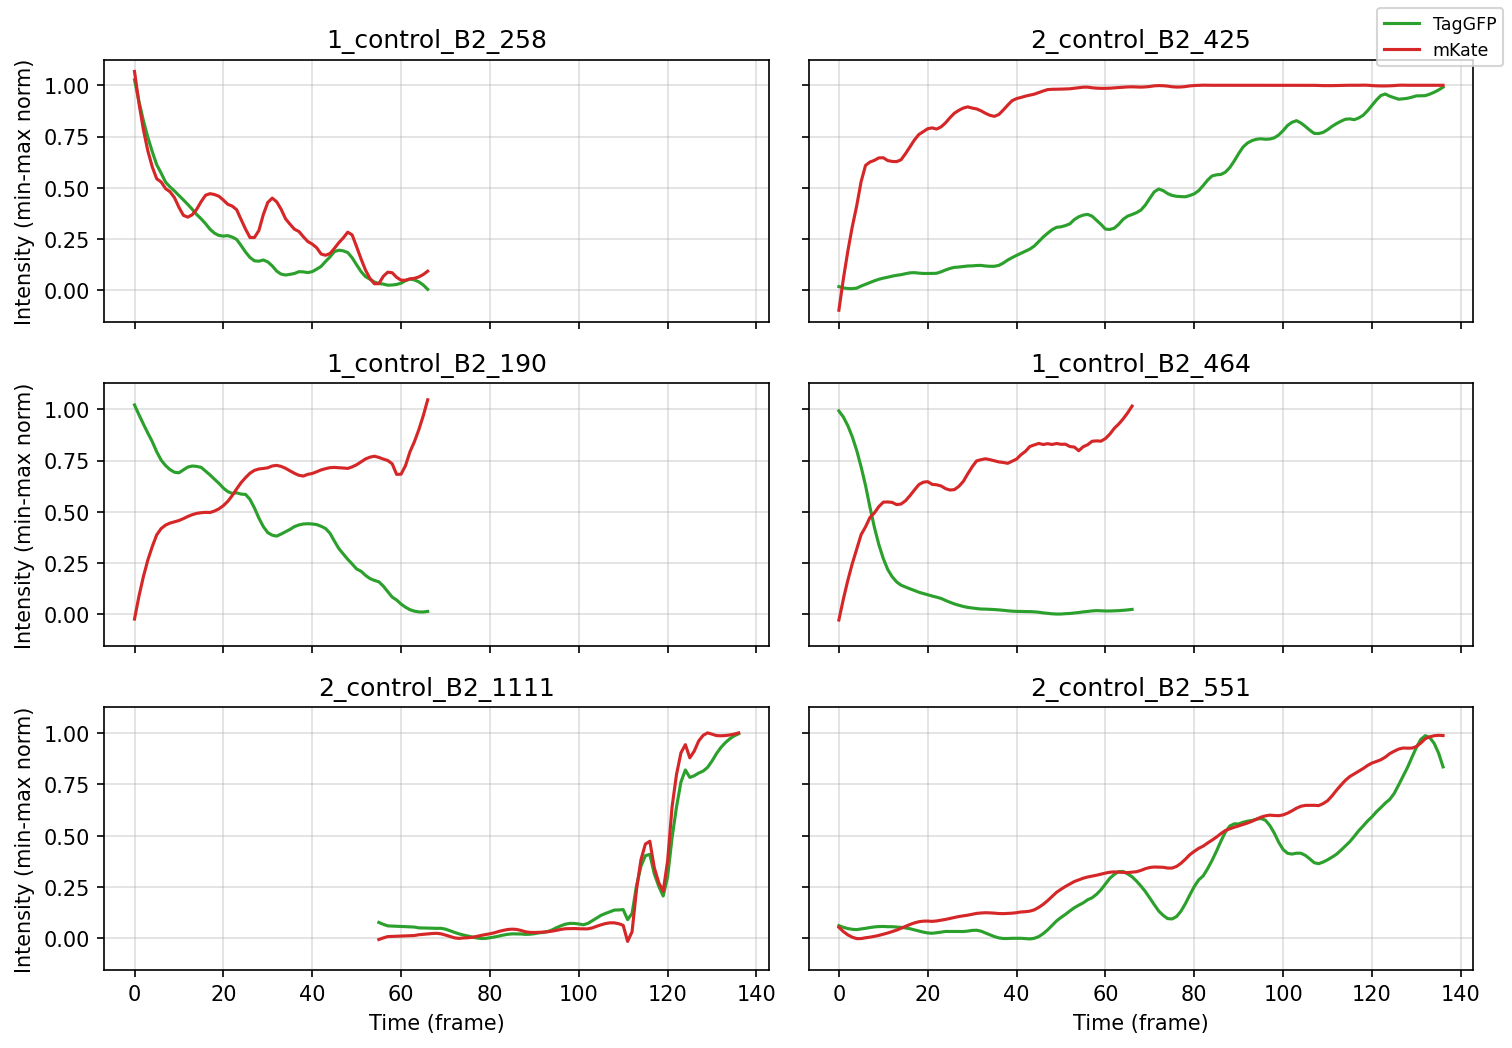

In [61]:
# # plot smoothed signals
# sampled_cells = np.random.choice(processed_df['particle_id'].unique(), size=6, replace=False)

# fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

# for idx, cell_id in enumerate(sampled_cells):
#     row, col = divmod(idx, 2)
#     ax = axes[row, col]
    
#     cdf = processed_df[processed_df['particle_id'] == cell_id].sort_values('frame')
    
#     ax.plot(cdf['frame'], cdf['TagGFP_processed'], label='TagGFP', color='tab:green')
#     ax.plot(cdf['frame'], cdf['mKate_processed'], label='mKate', color='tab:red')
#     # ax.plot(cdf['frame'], cdf['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
#     ax.set_title(f'{cell_id}')
#     ax.grid(True, alpha=0.4)
#     if row == 2: 
#         ax.set_xlabel('Time (frame)')
#     else:
#         ax.set_xlabel('')
#     if col == 0:
#         ax.set_ylabel('Intensity (min-max norm)')
#     else:
#         ax.set_ylabel('')
    
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize='small')

# plt.tight_layout()
# plt.show()

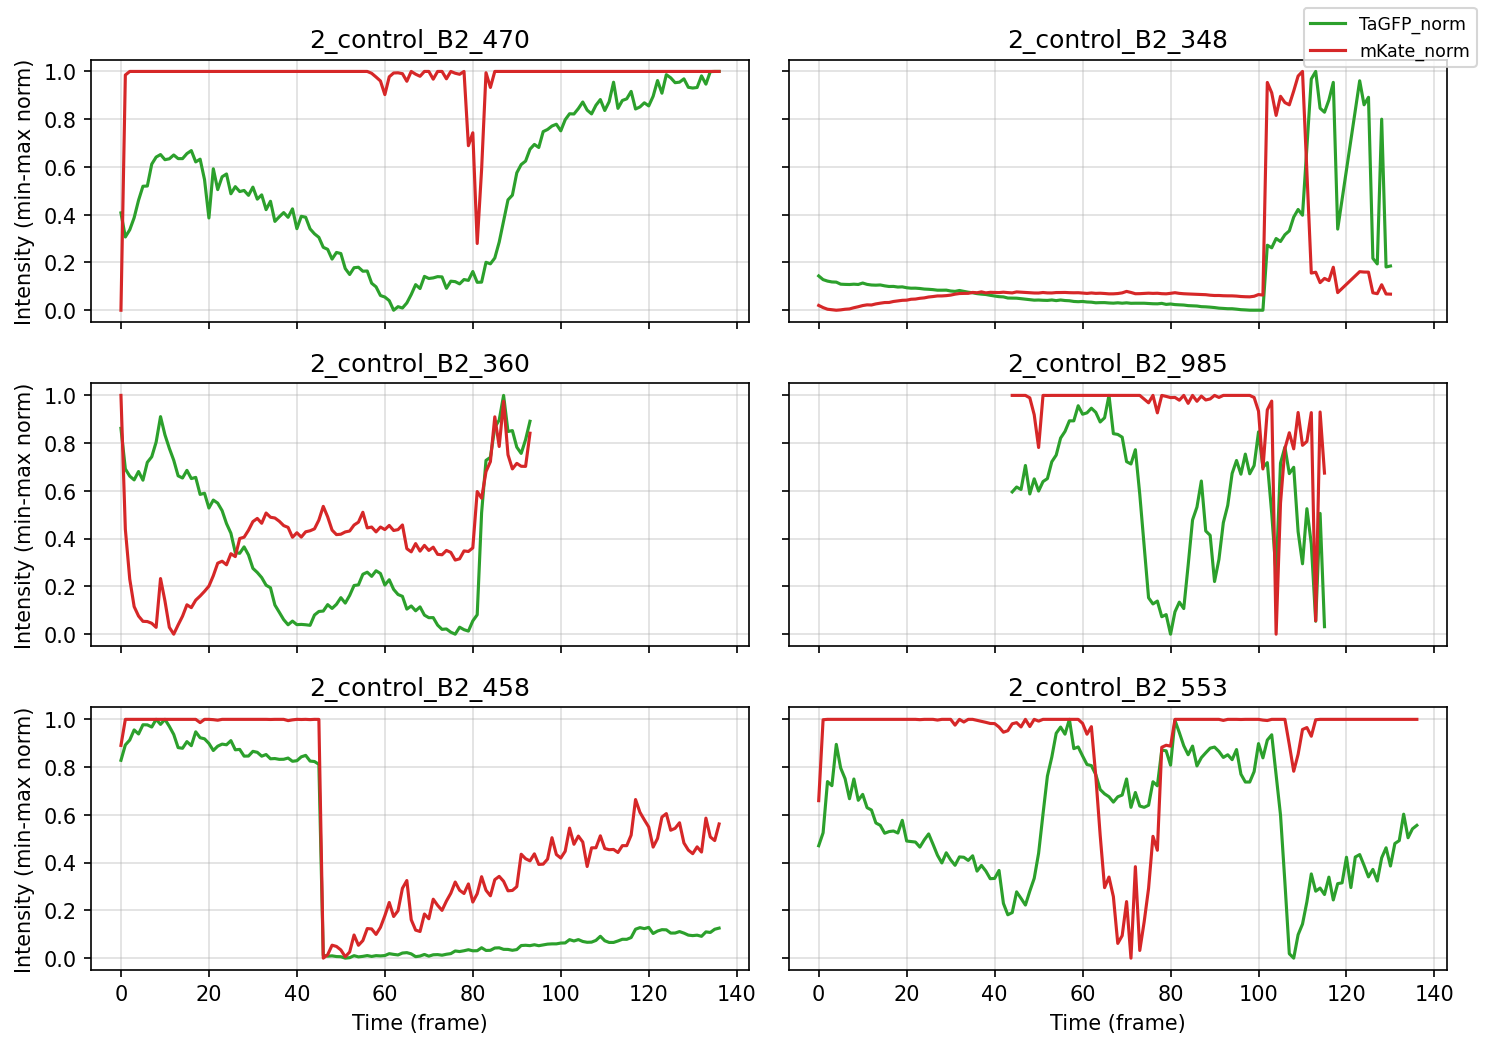

In [45]:
# # unnormalized
# fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

# for idx, cell_id in enumerate(sampled_cells):
#     row, col = divmod(idx, 2)
#     ax = axes[row, col]
    
#     cdf = tmp[tmp['particle_id'] == cell_id].sort_values('frame')
    
#     ax.plot(cdf['frame'], cdf['TaGFP_norm'], label='TaGFP_norm', color='tab:green')
#     ax.plot(cdf['frame'], cdf['mKate_norm'], label='mKate_norm', color='tab:red')
#     # ax.plot(cdf['frame'], cdf['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
#     ax.set_title(f'{cell_id}')
#     ax.grid(True, alpha=0.4)
#     if row == 2: 
#         ax.set_xlabel('Time (frame)')
#     else:
#         ax.set_xlabel('')
#     if col == 0:
#         ax.set_ylabel('Intensity (min-max norm)')
#     else:
#         ax.set_ylabel('')
    
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize='small')

# plt.tight_layout()
# plt.show()

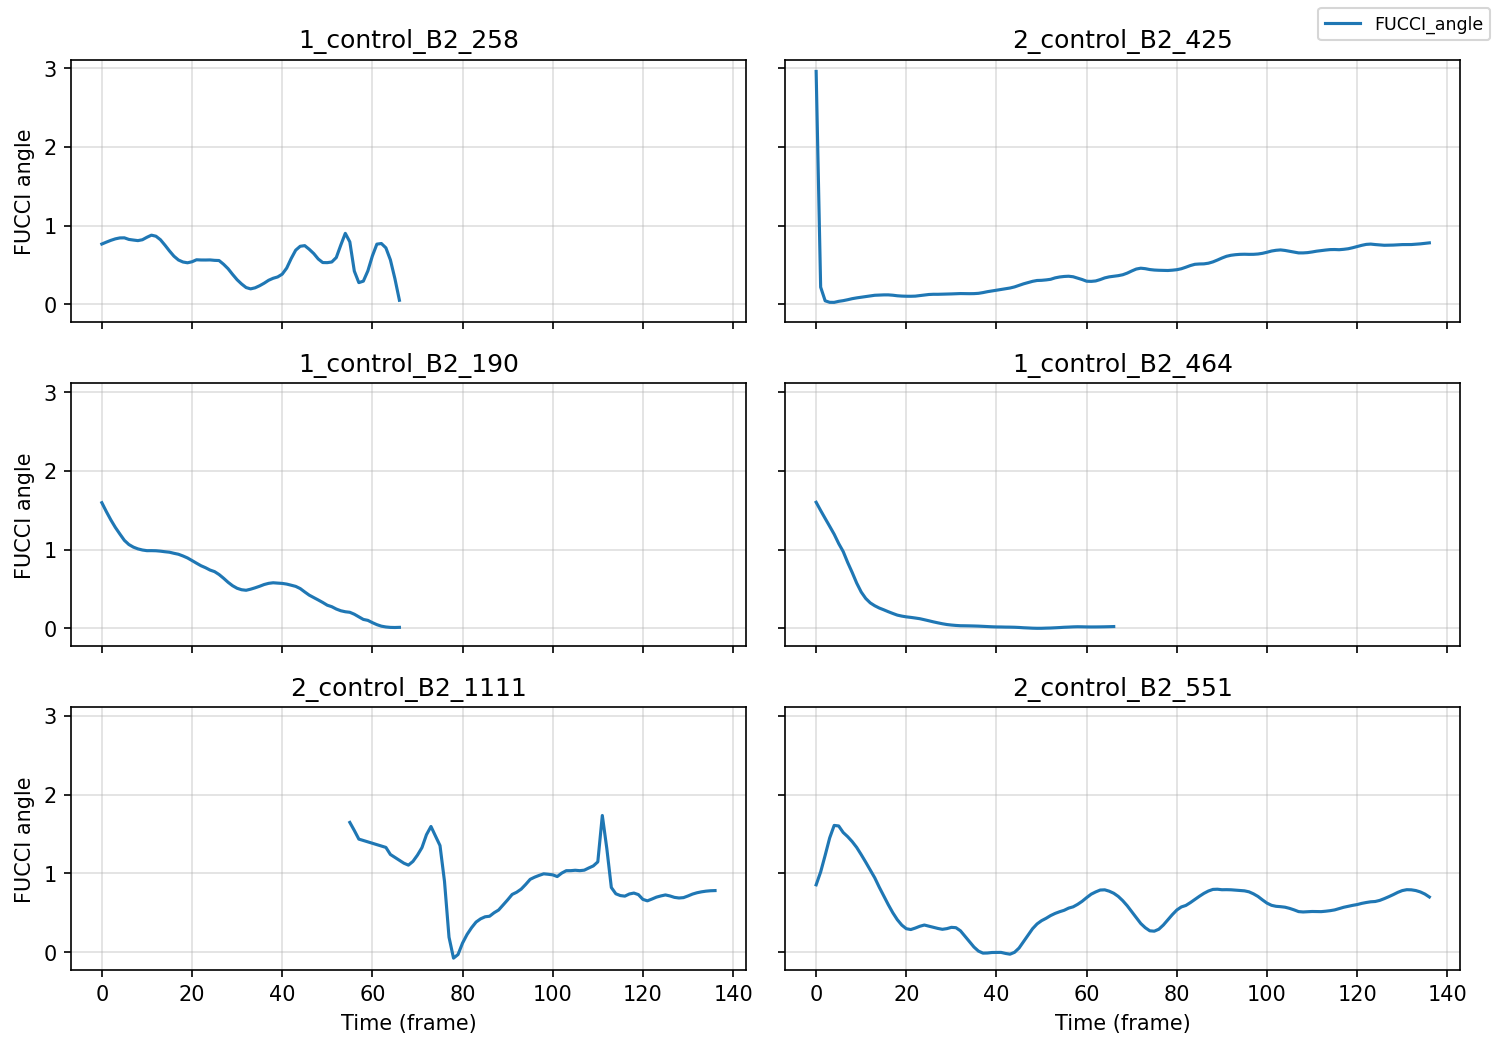

In [62]:
# # plot FUCCI angle
# # sampled_cells = np.random.choice(tmp['particle_id'].unique(), size=6, replace=False)

# fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

# for idx, cell_id in enumerate(sampled_cells):
#     row, col = divmod(idx, 2)
#     ax = axes[row, col]
    
#     cdf = processed_df[processed_df['particle_id'] == cell_id].sort_values('frame')
    
#     ax.plot(cdf['frame'], cdf['FUCCI_angle'], label='FUCCI_angle', color='tab:blue')
    
#     ax.set_title(f'{cell_id}')
#     ax.grid(True, alpha=0.4)
#     if row == 2: 
#         ax.set_xlabel('Time (frame)')
#     else:
#         ax.set_xlabel('')
#     if col == 0:
#         ax.set_ylabel('FUCCI angle')
#     else:
#         ax.set_ylabel('')
    
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize='small')

# plt.tight_layout()
# plt.show()

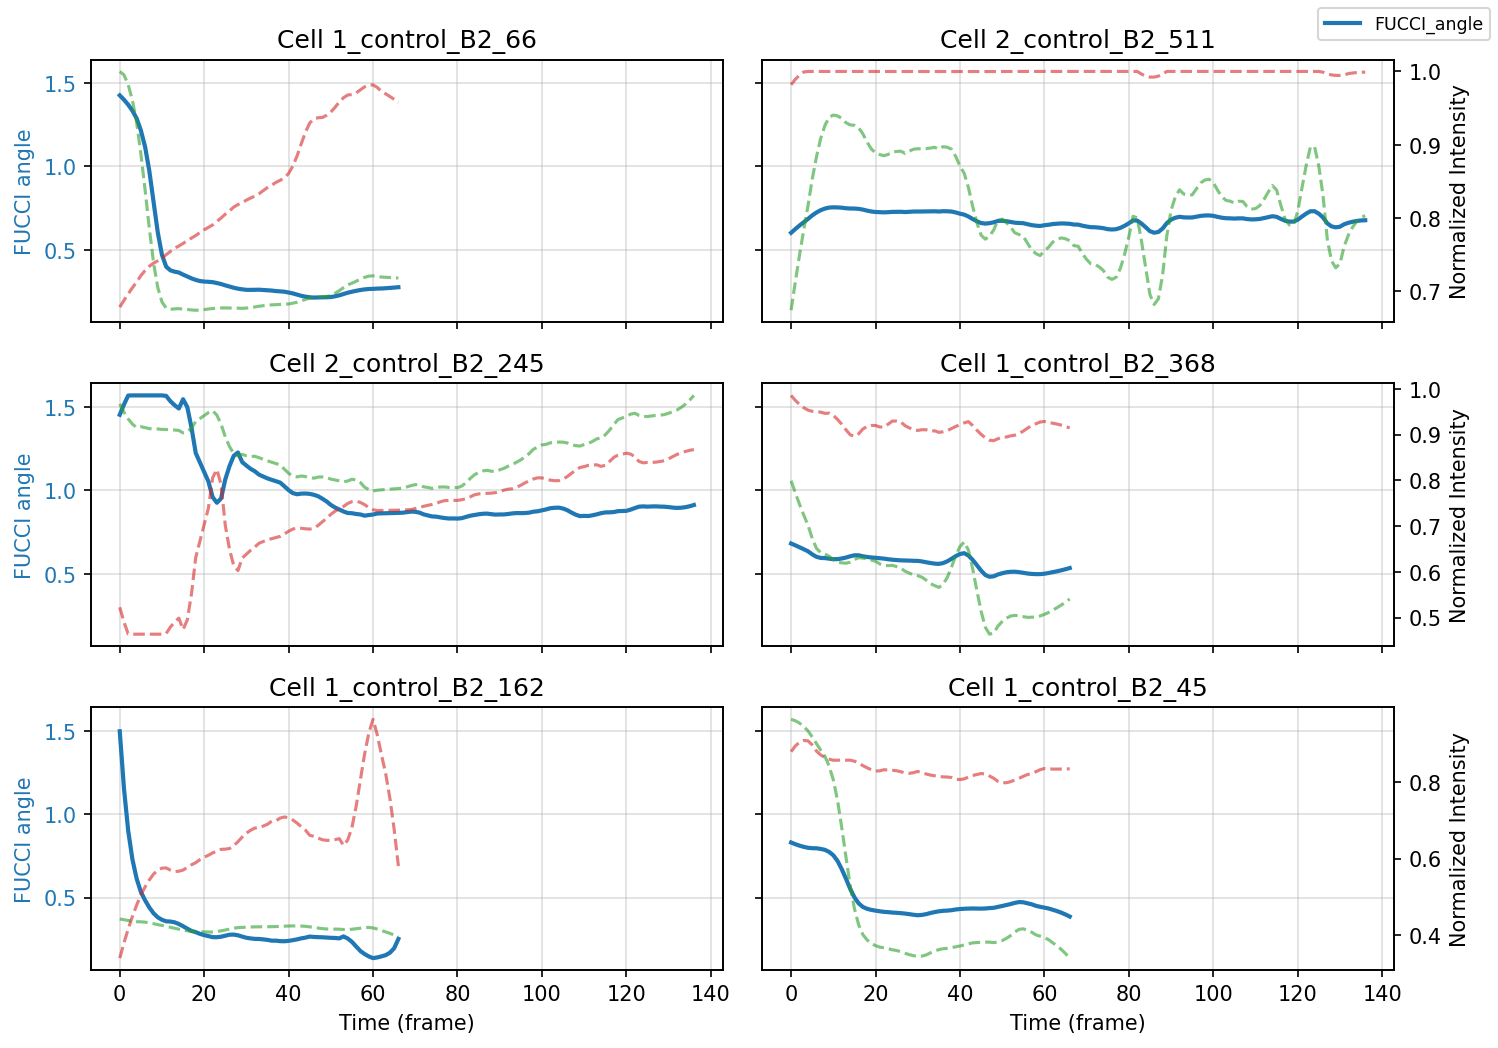

In [70]:
sampled_cells = np.random.choice(processed_df['particle_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    cdf = processed_df[processed_df['particle_id'] == cell_id].sort_values('frame')
    
    # Plot the angle on the left y-axis
    ax.plot(cdf['frame'], cdf['FUCCI_angle'], label='FUCCI_angle', color='tab:blue', linewidth=2)
    ax.set_ylabel('FUCCI angle' if col == 0 else '', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    
    # Create a second y-axis to overlay the actual smoothed intensities
    ax2 = ax.twinx()
    ax2.plot(cdf['frame'], cdf['mKate_processed'], label='mKate (Red)', color='tab:red', alpha=0.6, linestyle='--')
    ax2.plot(cdf['frame'], cdf['TagGFP_processed'], label='TagGFP (Green)', color='tab:green', alpha=0.6, linestyle='--')
    if col == 1:
        ax2.set_ylabel('Normalized Intensity')
    else:
        ax2.get_yaxis().set_visible(False) # Hide right y-axis tick labels on the left column
        
    ax.set_title(f'Cell {cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: ax.set_xlabel('Time (frame)')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

# good switches

1_control_B2_190
1_control_B2_464

In [71]:
# 1. Flag Mitosis first (where total pool collapses)
processed_df['Total_Intensity'] = processed_df['mKate_processed'] + processed_df['TagGFP_processed']
is_mitosis = processed_df['Total_Intensity'] < 0.15  # Adjust slightly if needed

# 2. Gate the phases based on the clean angle thresholds
conditions = [
    is_mitosis,                                                  # M Phase
    (~is_mitosis) & (processed_df['FUCCI_angle'] < 0.4),          # G1 Phase
    (~is_mitosis) & (processed_df['FUCCI_angle'].between(0.4, 0.75)), # S Phase
    (~is_mitosis) & (processed_df['FUCCI_angle'] > 0.75)          # G2 Phase
]

choices = ['M', 'G1', 'S', 'G2']

processed_df['Cell_Cycle_Phase'] = np.select(conditions, choices, default='Unknown')

In [76]:
def advanced_cell_cycle_classifier(group):
    if len(group) < 5:
        return group
    
    # --- 1. DYNAMIC MITOSIS DETECTION (Velocity-based) ---
    gfp_velocity = group['TagGFP_processed'].diff(1)
    total_intensity = group['mKate_processed'] + group['TagGFP_processed']
    
    is_mitotic_frame = (gfp_velocity < -0.15) & (total_intensity < 0.4)
    
    # --- 2. CONDITION-BASED GATING (Biology-First) ---
    red = group['mKate_processed']
    green = group['TagGFP_processed']
    angle = group['FUCCI_angle']
    
    phases = []
    for r, g, ang, is_m in zip(red, green, angle, is_mitotic_frame):
        if is_m:
            phases.append('M')
        elif r > 0.3 and g < 0.2:
            phases.append('G1')
        elif g > 0.4 and r < 0.3:
            phases.append('G2')
        elif r > 0.2 and g > 0.2:
            phases.append('S')
        else:
            if ang < 0.4:
                phases.append('G1')
            elif ang > 0.75:
                phases.append('G2')
            else:
                phases.append('S')
                
    # Convert list to pandas Series
    phase_series = pd.Series(phases, index=group.index)
    
    # --- 3. TEMPORAL CLEANUP (Correct string-compatible method) ---
    # We look at the current frame, the frame before, and the frame after.
    # If a frame is surrounded by a different phase (e.g., 'G2', 'M', 'G2'), 
    # it forces it to match its neighbors, smoothly wiping out 1-frame glitches.
    prev_frame = phase_series.shift(1)
    next_frame = phase_series.shift(-1)
    
    # If neighbors match each other but not the current frame, take the neighbor value
    glitch_mask = (prev_frame == next_frame) & (phase_series != prev_frame)
    phase_series = np.where(glitch_mask, prev_frame, phase_series)
    
    # Forward/backward fill any edge NaNs created by the shift operations
    group['Cell_Cycle_Phase'] = pd.Series(phase_series, index=group.index).ffill().bfill()
    
    return group

# Run the updated, bug-free classifier
processed_df = processed_df.groupby('particle_id', group_keys=False).apply(advanced_cell_cycle_classifier)

/tmp/ipykernel_1698142/734757944.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  processed_df = processed_df.groupby('particle_id', group_keys=False).apply(advanced_cell_cycle_classifier)


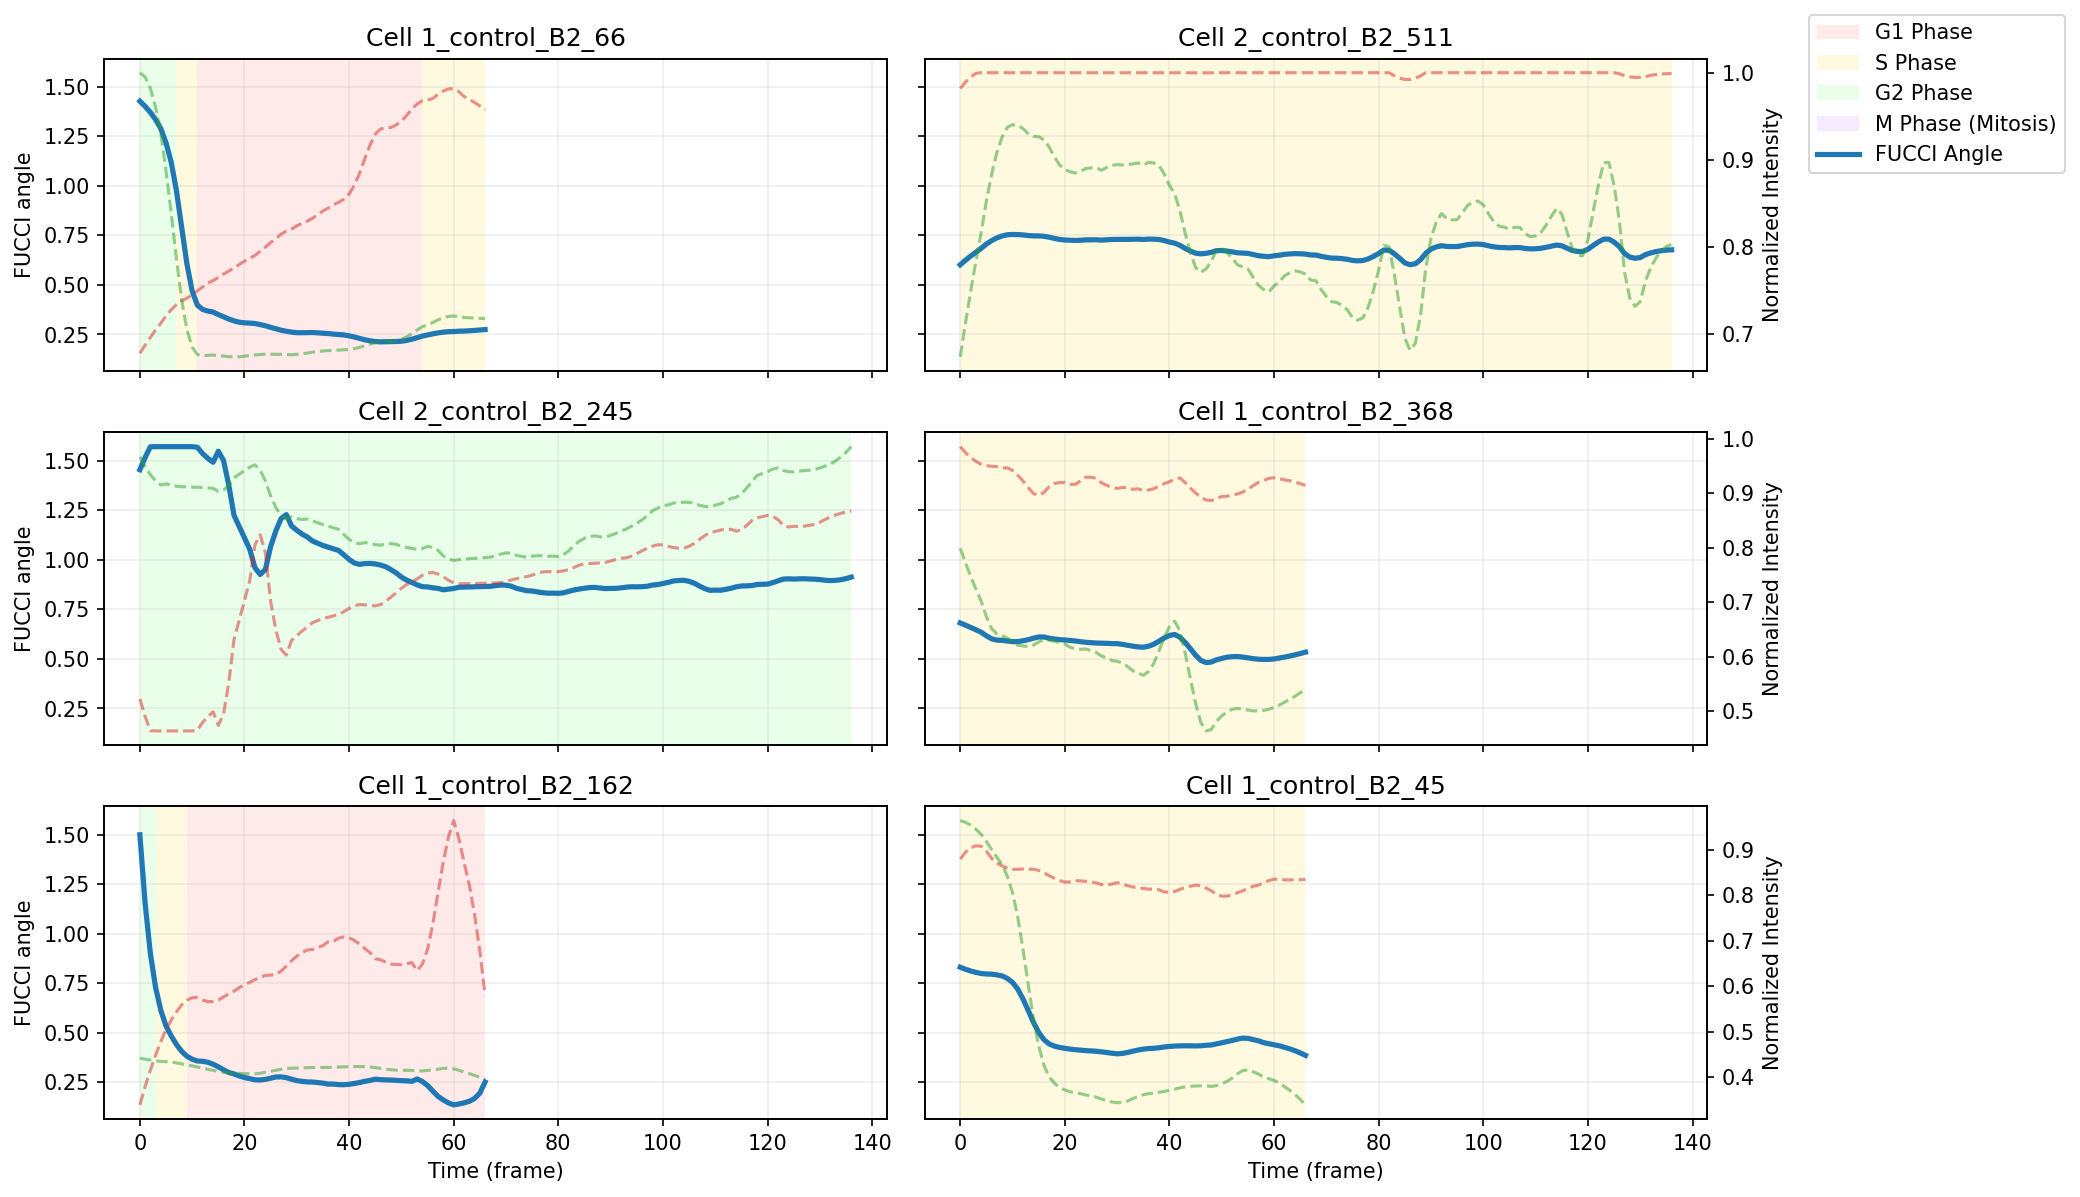

In [77]:
phase_colors = {
    'G1': '#ffcccc',  # Light Red
    'S':  '#fff0b3',  # Light Yellow / Gold
    'G2': '#ccffcc',  # Light Green
    'M':  '#e6ccff'   # Light Purple / Mitosis collapse
}

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    # Filter and sort data for the current cell
    cdf = processed_df[processed_df['particle_id'] == cell_id].sort_values('frame').reset_index(drop=True)
    
    # 1. Plot the FUCCI angle and individual channels
    ax.plot(cdf['frame'], cdf['FUCCI_angle'], label='FUCCI_angle', color='tab:blue', linewidth=2.5, zorder=3)
    
    ax2 = ax.twinx()
    ax2.plot(cdf['frame'], cdf['mKate_processed'], color='tab:red', alpha=0.5, linestyle='--', zorder=2)
    ax2.plot(cdf['frame'], cdf['TagGFP_processed'], color='tab:green', alpha=0.5, linestyle='--', zorder=2)
    
    if col == 1:
        ax2.set_ylabel('Normalized Intensity')
    else:
        ax2.get_yaxis().set_visible(False)

    # 2. Map the phases visually onto the background using axvspan
    # Loop through the track frame-by-frame to shade the background
    for i in range(len(cdf) - 1):
        start_frame = cdf.loc[i, 'frame']
        end_frame = cdf.loc[i+1, 'frame']
        phase = cdf.loc[i, 'Cell_Cycle_Phase']
        
        if phase in phase_colors:
            ax.axvspan(start_frame, end_frame, color=phase_colors[phase], alpha=0.4, lw=0)

    # Aesthetics
    ax.set_title(f'Cell {cell_id}')
    ax.grid(True, alpha=0.2)
    ax.set_ylabel('FUCCI angle' if col == 0 else '')
    if row == 2: ax.set_xlabel('Time (frame)')

# Create a custom legend for the background phases
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=phase_colors['G1'], alpha=0.4, label='G1 Phase'),
    Patch(facecolor=phase_colors['S'], alpha=0.4, label='S Phase'),
    Patch(facecolor=phase_colors['G2'], alpha=0.4, label='G2 Phase'),
    Patch(facecolor=phase_colors['M'], alpha=0.4, label='M Phase (Mitosis)'),
    plt.Line2D([0], [0], color='tab:blue', lw=2.5, label='FUCCI Angle')
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()